This lab is adapted from the IBM Quantum Learning module “Quantum teleportation” on the IBM Quantum platform
(see https://quantum.cloud.ibm.com/learning/en/modules/computer-science/quantum-teleportation).

Import libraries

In [1]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.primitives import BackendSamplerV2
from IPython.display import Image
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.visualization import plot_circuit_layout, plot_gate_map
from qiskit.visualization import plot_histogram

## Introduction

Quantum teleportation is a protocol that uses shared entanglement and classical communication to transfer an unknown qubit state from 'Alice' to 'Bob' without moving the physical qubit. The protocol proceeds as follows.

Qubits $A$ and $B$ are initially prepared in a maximally entangled state, with Alice holding $A$ and the input qubit $Q$, and Bob holding $B$. Alice first performs a controlled NOT operation on the pair $(A,Q)$, with $Q$ as the control and $A$ as the target, and then applies a Hadamard gate to $Q$. She then measures both $A$ and $Q$ in the computational basis and sends the two classical outcomes to Bob. The result of the measurement on $A$ is denoted by $a$ and the result of the measurement on $Q$ is denoted by $b$. 

When Bob receives $a$ and $b$, he applies a correction to his qubit $B$ that depends on these bits. If $a = 1$ he applies a bit flip $X$ to $B$, and if $b = 1$ he applies a phase flip $Z$ to $B$. This is the complete description of the teleportation protocol. 

The analysis below shows that after the protocol has been executed, the qubit $B$ is in exactly the same state that $Q$ was in before the protocol, including any correlations that $Q$ had with other systems, so the protocol effectively implements a perfect qubit communication channel in which the state of $Q$ has been teleported into $B$. 

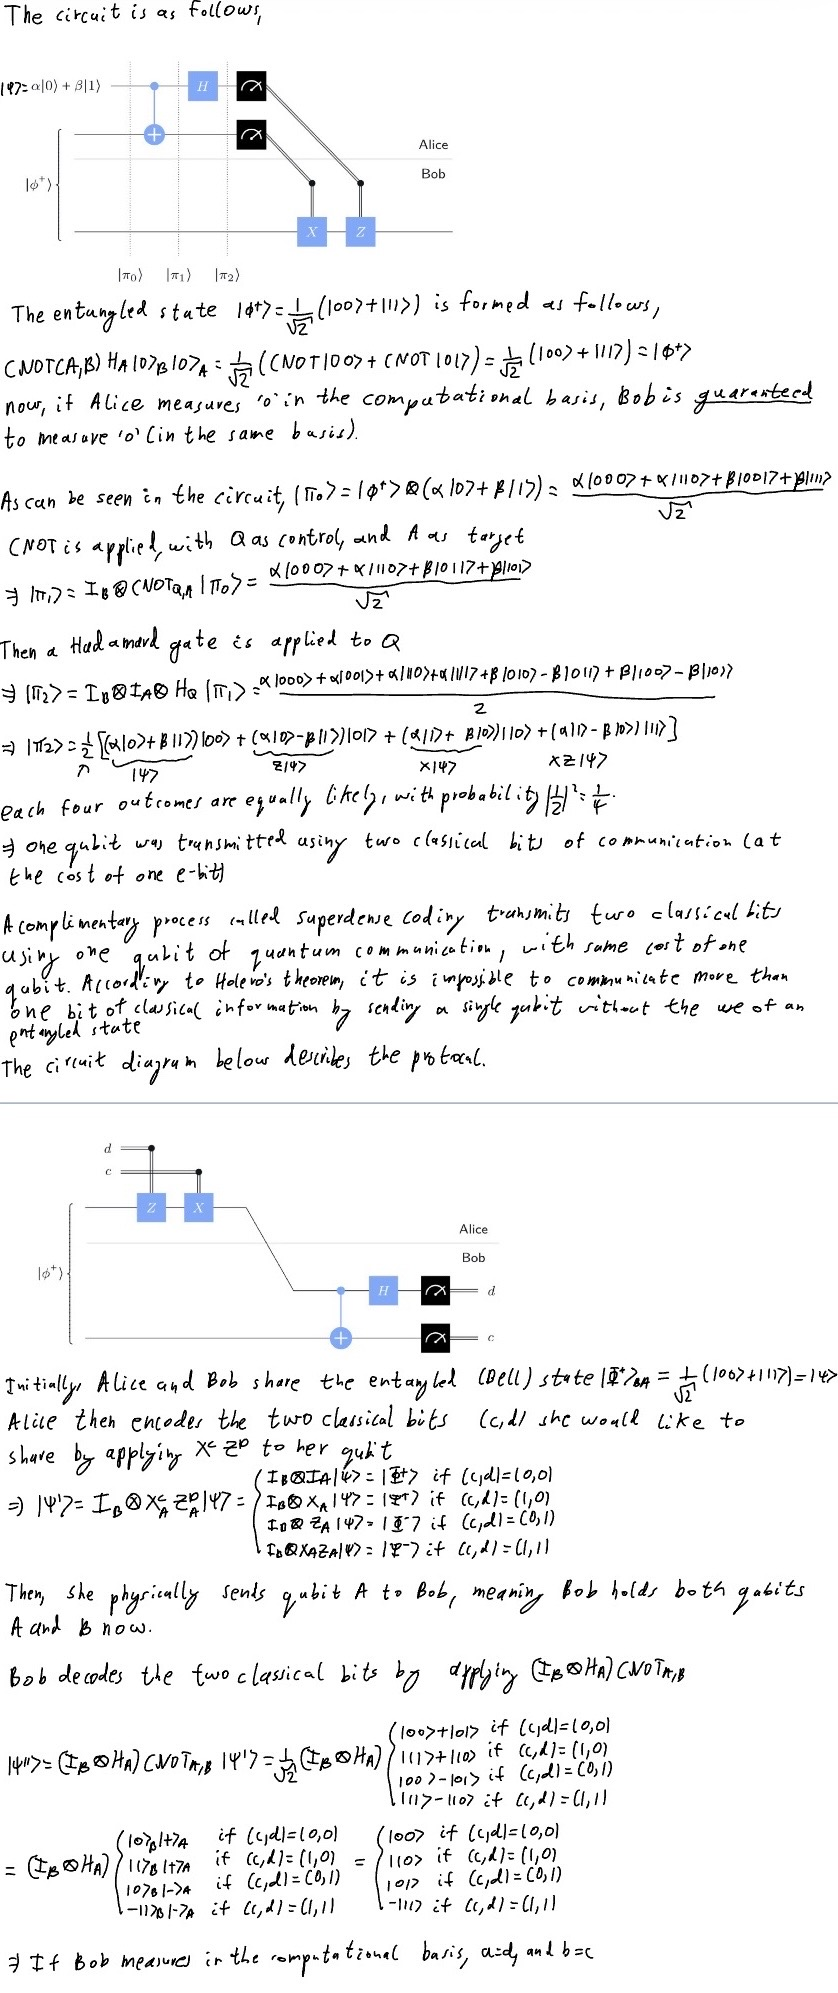

In [11]:
Image('teleportation_protocol.jpg')

Since all of the gates are unitary (and therefore have inverses), Bob can apply inverses of the gates shown under $|\pi_2\rangle$. If Alice measures the state $|00\rangle_{AQ}$, Bob does nothing, if Alice measures $|01\rangle_{AQ}$ Bob applies $Z^{-1}=Z$, if Alice measures $|10\rangle_{AQ}$ Bob applies $X^{-1}=X$, if she measures $|11\rangle_{AQ}$ he applies $\left(XZ\right)^{-1}=ZX$ ($X$ and then $Z$). After this step, Bob now holds the state $|\psi\rangle$.

Note that this protocol does not clone the state of $Q$, which would contradict the no cloning theorem. Once the protocol is finished, the state of $Q$ has changed from its original value to $|b\rangle$ as a result of the measurement. The shared entangled pair has been lost in the process, since the state of $A$ has collapsed to $|a\rangle$ and is no longer entangled with $B$ or any other system.

A more general example below shows that if $Q$ is initially entangled with another system $R$, then after the protocol Bob’s qubit $B$ is entangled with $R$ in exactly the same way as $Q$ was before!

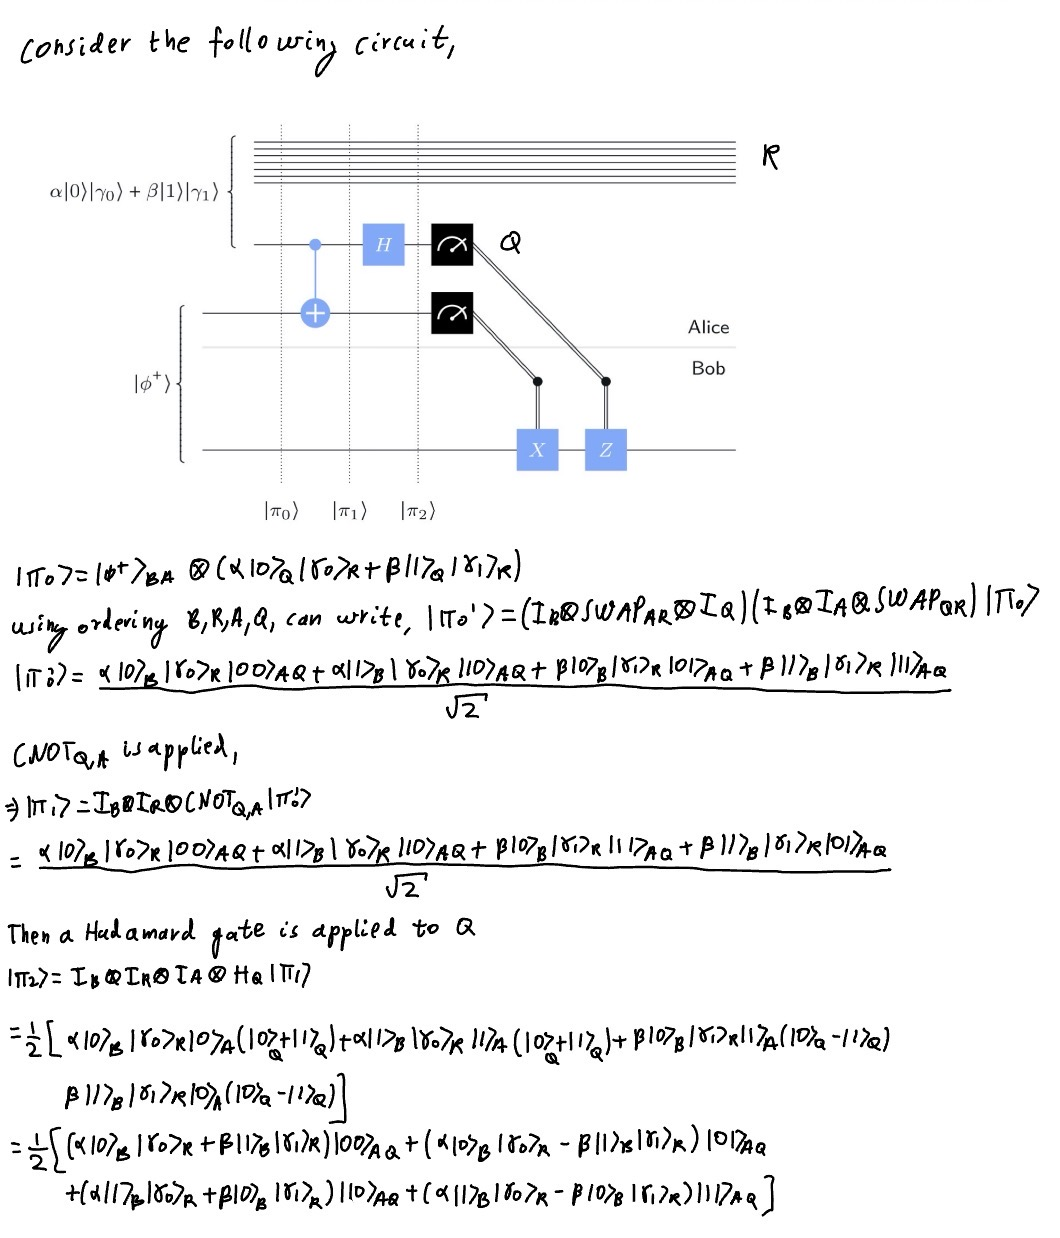

In [10]:
Image('teleportation_r.jpg')

## Experiment 1: Basic teleportation


This procedure is exactly followed on quantum hardware below.

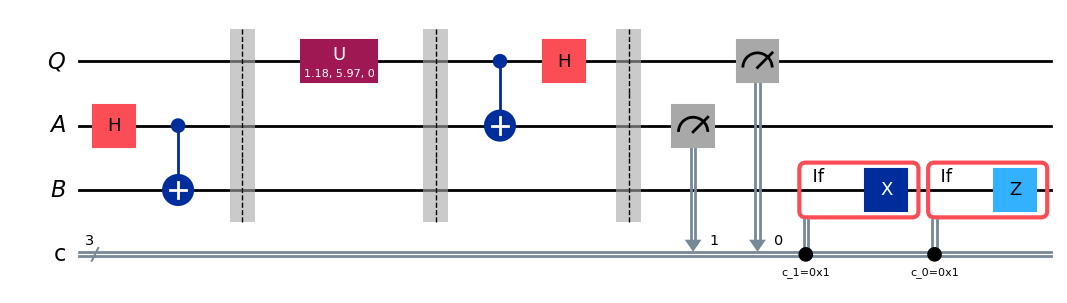

In [1]:
# Step 1: Map your problem to a quantum circuit
 
# Import some general packages

 
# Define registers
secret = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")
 
cr = ClassicalRegister(3, "c")
 
qc = QuantumCircuit(secret, Alice, Bob, cr)
 
# We entangle Alice's and Bob's qubits as in our work above. We apply a Hadamard gate and then a CNOT gate.
# Note that the second argument in the CNOT gate is the target.
qc.h(Alice)
qc.cx(Alice, Bob)
 
# Inserting a barrier changes nothing about the logic. It just allows us to force gates to be positioned in "layers".
qc.barrier()
 
# Now we will use random variables to create the secret state. Don't worry about the "u" gate and the details.
np.random.seed(42)  # fixing seed for repeatability
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi
 
# Assign the secret state to the qubit on the other side of Alice's (qubit 0), labeled Q
qc.u(theta, varphi, 0.0, secret)
qc.barrier()
 
# Now entangle Q and Alice's qubits as in the discussion above.
qc.cx(secret, Alice)
qc.h(secret)
qc.barrier()
 
# Now Alice measures her qubits, and stores the outcomes in the "classical registers" cr[]
qc.measure(Alice, cr[1])
qc.measure(secret, cr[0])
 
# Now we insert some conditional logic. If Alice measures Q in a "1" we need a Z gate, and if Alice measures A in a "1" we need an X gate (see the table).
with qc.if_test((cr[1], 1)):
    qc.x(Bob)
with qc.if_test((cr[0], 1)):
    qc.z(Bob)
 
qc.draw(output="mpl")

This will teleport the state $\alpha_0|0\rangle+\alpha_1|1\rangle$ to Bob, however this needs to be verified. Measuring the state will give $|0\rangle$ with probability $|\alpha_0|^2$ or $|1\rangle$ with probability $|\alpha_1|^2$, although since measurement collapses the state, statistics cannot be measured using this single shot. To verify if the state is exactly what Alice sent, Bob applies the inverse of the unitary operator Alice applied. If the state he measures is $|0\rangle$, the teleportation worked.

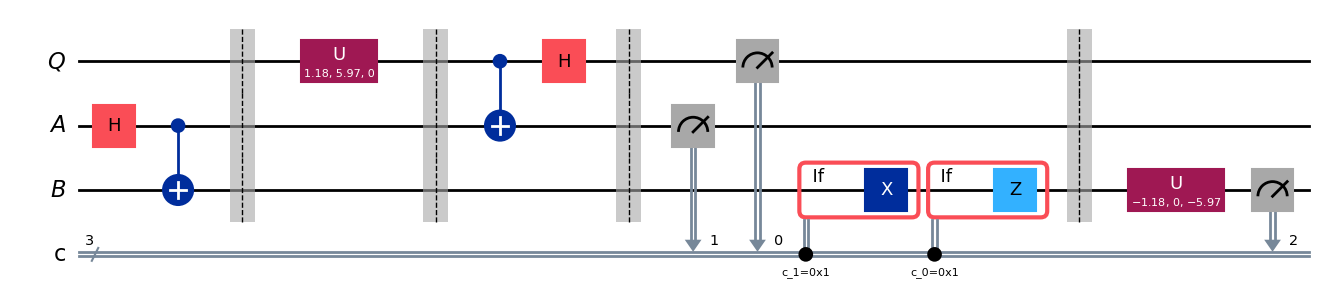

In [2]:
# Add the inverse of U and measure Bob's qubit.
qc.barrier()
 
qc.u(theta, varphi, 0.0, Bob).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(Bob, cr[2])  # add measurement gate
 
qc.draw(output="mpl")

In [3]:
# Load saved credentials
service = QiskitRuntimeService()
 
# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

management.get:WARNING:2025-10-20 21:22:55,650: Loading default saved account


ibm_torino


In [5]:
# Step 2: Transpile

 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

In [6]:
# Load the Runtime primitive and session

 
sampler = Sampler(mode=backend)

In [7]:
# Load the backend sampler

 
# Load the Aer simulator and generate a noise model based on the currently-selected backend.

 
 
noise_model = NoiseModel.from_backend(backend)
 
# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)
 
# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

In [8]:
job = sampler.run([qc_isa])#defaults to 5000
# job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.c.get_counts()

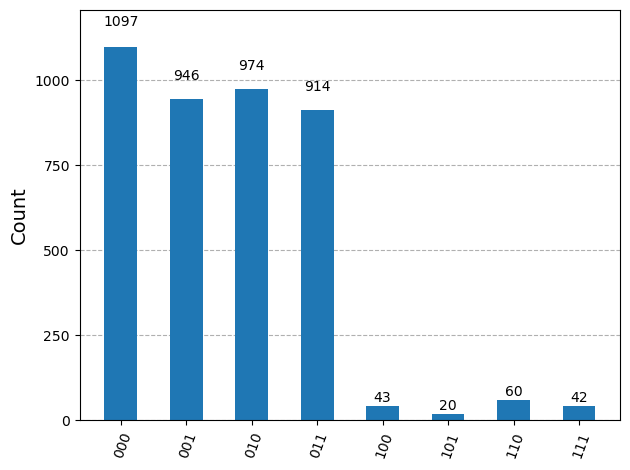

In [9]:
# This required 5 s to run on a Heron r2 processor on 10-28-24
plot_histogram(counts)

Teleportation is successful for any outcome whose most significant bit, corresponding to $B$, is $0$. Up to hardware noise, this happens for ~ all $5000$ shots (the circuit is prepared and run $5000$ times).

## Experiment 2: Teleporting across a processor


In principle, the state of qubit $Q$ could be moved to $B$ using only SWAP gates, for example by swapping $Q$ with $A$ and then $A$ with $B$. One advantage of teleportation however is that it works even when the qubits are far apart. In the circuit below, this is shown by first entangling Alice’s and Bob’s qubits, then 'separating' them by applying five SWAP gates to Bob’s qubit (moving it down five positions) and five SWAP gates to Alice’s qubit (moving it up five positions), and finally running the standard teleportation protocol. Although this exact procedure is inefficient, if the qubits were already that far apart, the teleportation step would remain very useful.

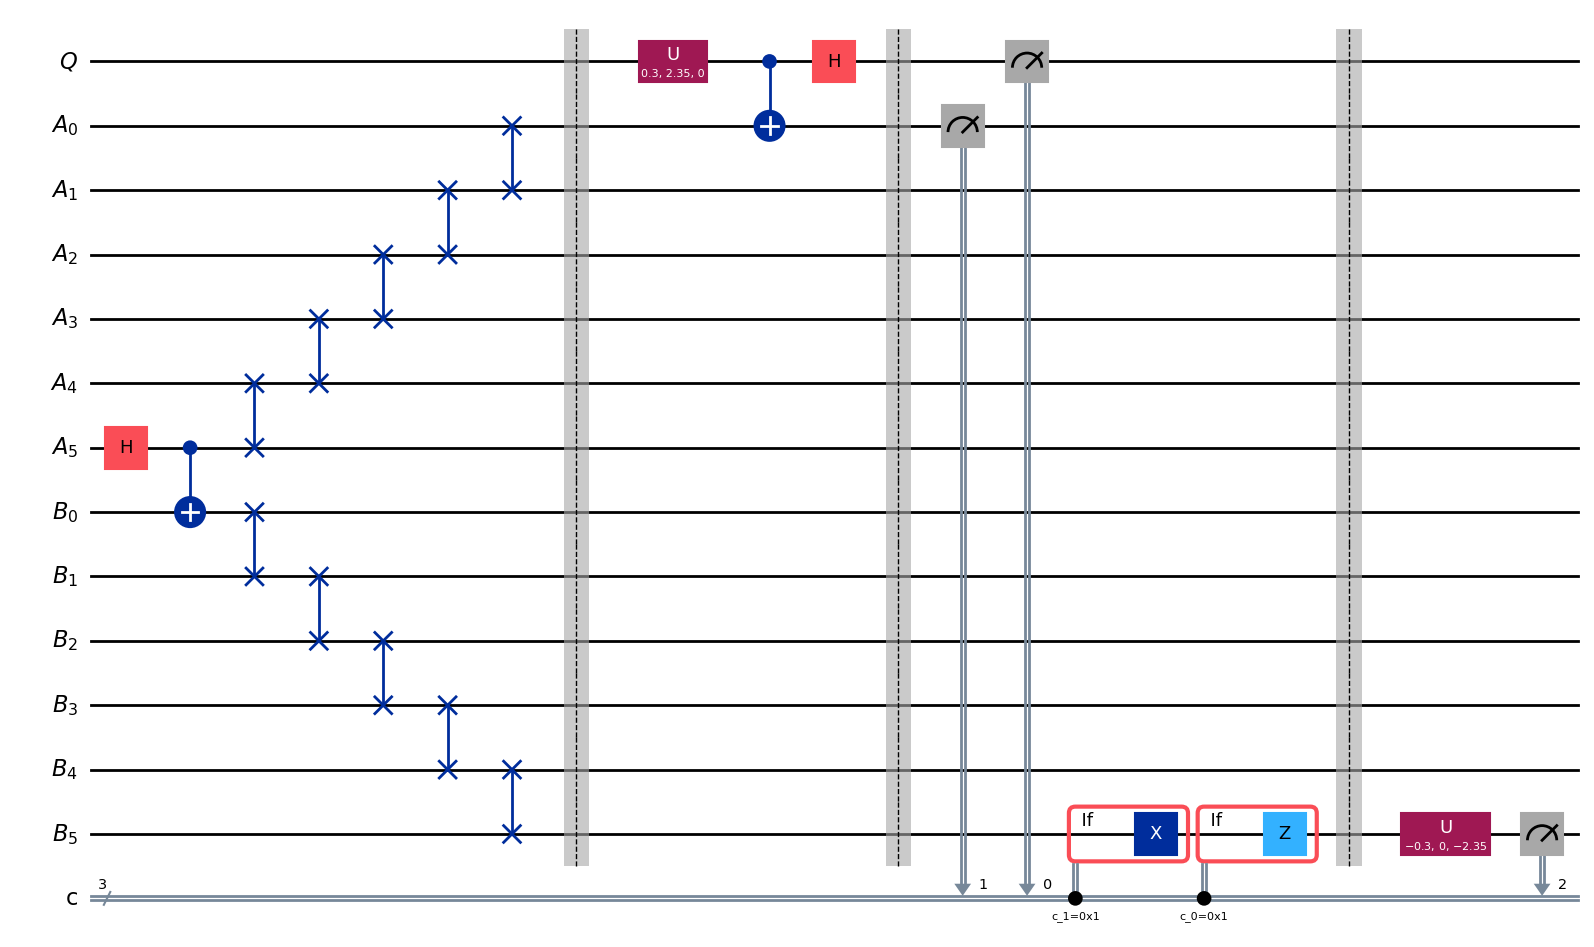

In [10]:
# Step 1: Map
 
# Define registers
qr = QuantumRegister(13, "q")
 
qc = QuantumCircuit(qr, cr)
 
# Define registers
secret = QuantumRegister(1, "Q")
ebitsa = QuantumRegister(6, "A")
ebitsb = QuantumRegister(6, "B")
# q = ClassicalRegister(1, "q meas")
# a = ClassicalRegister(1, "a")
# b = ClassicalRegister(1, "b")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(secret, ebitsa, ebitsb, cr)
 
# We'll start Alice in the middle of the circuit, then move information outward in both directions.
Alice = 5
Bob = 0
qc.h(ebitsa[Alice])
qc.cx(ebitsa[Alice], ebitsb[Bob])
 
# Starting with Bob and Alice in the center, we swap their information onto adjacent qubits, until the information is on distant qubits.
 
for n in range(Alice):
    qc.swap(ebitsb[Bob], ebitsb[Bob + 1])
    qc.swap(ebitsa[Alice], ebitsa[Alice - 1])
    Alice = Alice - 1
    Bob = Bob + 1
 
qc.barrier()
 
# Create a random state for Alice (qubit zero)
np.random.seed(42)  # fixing seed for repeatability
# theta = np.random.uniform(0.0, 1.0) * np.pi    #from 0 to pi
theta = 0.3
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi
 
 
qc.u(theta, varphi, 0.0, secret)
 
# Entangle Alice's two qubits
qc.cx(secret, ebitsa[Alice])
qc.h(secret)
 
qc.barrier()
 
# Make measurements of Alice's qubits and store the results in the classical register.
qc.measure(ebitsa[Alice], cr[1])
qc.measure(secret, cr[0])
 
# Send instructions to Bob's qubits based on the outcome of Alice's measurements.
with qc.if_test((cr[1], 1)):
    qc.x(ebitsb[Bob])
with qc.if_test((cr[0], 1)):
    qc.z(ebitsb[Bob])
 
qc.barrier()

#who is Carl??

# Invert the preparation we did for Carl's qubit so we can check whether we did this correctly.
qc.u(theta, varphi, 0.0, ebitsb[Bob]).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(ebitsb[Bob], cr[2])  # add measurement gate
 
qc.draw("mpl")

In [11]:
# Step 2: Transpile

 
target = backend.target
pmzero = generate_preset_pass_manager(target=target, optimization_level=0)
 
qc_isa_zero = pmzero.run(qc)
 
print(qc_isa_zero.depth())

55


Since the process is inefficient, any circuit optimization would undo the 'unnecessary' SWAP gates, so no optimization is used. Depth of 55 means that 55 'time steps' are needed.

In [12]:
# This required 5 s to run on a Heron r2 processor on 10-28-24
job = sampler.run([qc_isa_zero])
# job = sampler_sim.run([qc_isa_zero])
counts = job.result()[0].data.c.get_counts()

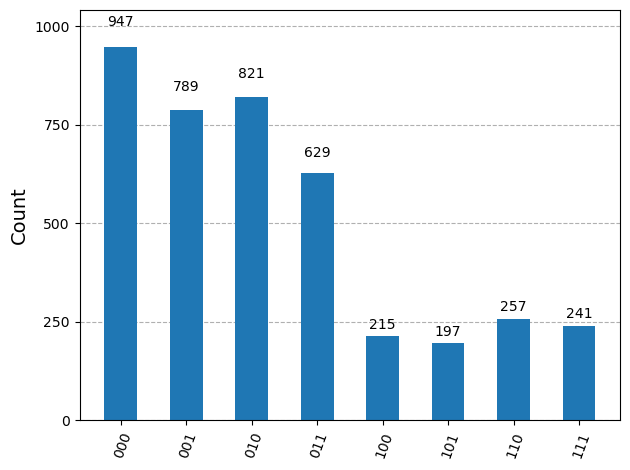

In [13]:

plot_histogram(counts)

As before, teleportation is successful for any outcome whose most significant bit is $0$. Since the circuit is deeper, more hardware noise effects are seen in the results.

## Conclusion

Teleportation was implemented on quantum hardware and verified by reversing the state preparation on Bob’s qubit, confirming that the unknown input state was successfully transferred. The protocol was then repeated with Alice’s and Bob’s qubits separated across the processor using SWAP gates, showing that teleportation still works over longer device distances, although increased circuit depth leads to more noise in the results.

## Questions

**True/False Questions**

1. *Quantum teleportation can be used to send information faster than light.*


**False**, teleportation needs classical communication which is light speed limited.

2. *Modern evidence suggests that the collapse of a quantum state propagates faster than light.*


**True**, when one particle is measured, the state of its distant entangled particle collapses faster than a light signal could travel between them. This does not allow for faster than light communication, but it does suggest that the quantum correlation is non-local.

3. *In Qiskit the lowest numbered qubit is on the right as in* $|q_3,q_2,q_1,q_0\rangle$  

**True**, Qiskit uses little endian.

**Multiple Choice Questions**

1. Qubits $A$ and $B$ are entangled, then separated by a great distance $d$. Qubit $A$ is measured. Which statement is correct about the speed at which the state of qubit $B$ is affected?

*a. Qubit $B$ is affected instantly, within experimental tolerance, in experiments run so far.*

*b. Qubit $B$ is affected after a time $d/c$, meaning the quantum state "collapses" at approximately the speed of light, within experimental tolerance.*

*c. Qubit B is affected only after classical communication has occurred, meaning it happens in a time longer than $d/c$*.

*d. None of the above*

**a**

2. *Recall that measurement probability is related to amplitudes in quantum states. For example, if a qubit is initially in the state $\alpha_0|0\rangle+\alpha_1|1\rangle$ the probability of measuring the state $|0\rangle$ is $|\alpha_0|^2$. Not all sets of measurements will exactly match these probabilities, due to finite sampling (just as flipping a coin might yield heads twice in a row). The measurement histogram below could correspond to which of the following quantum states? Select the best option.*

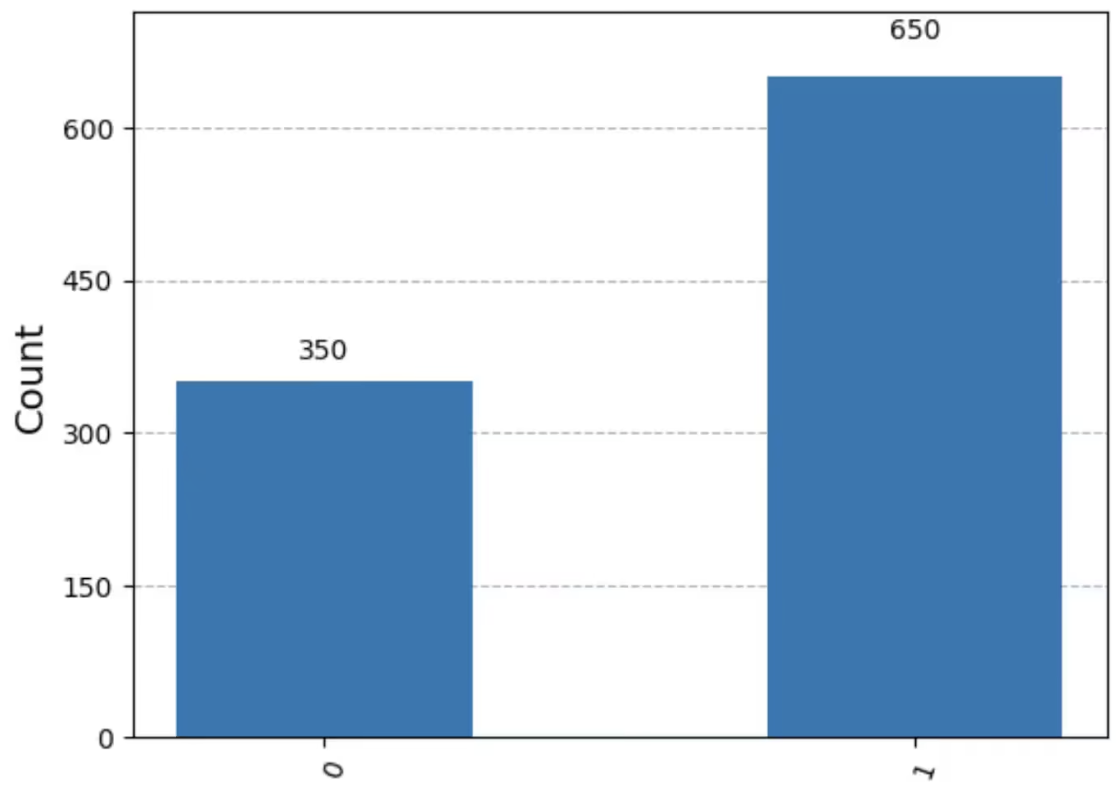

In [3]:
Image('teleportation2.png',width=600)

*a.* $|0\rangle$

*b.* $\frac{1}{\sqrt{2}}\left(|0\rangle-|1\rangle\right)$

*c.* $\frac{1}{\sqrt{2}}\left(|0\rangle+|1\rangle\right)$

*d.* $\frac{4}{5}|0\rangle+\frac{3}{5}|1\rangle$

*e.* $\frac{3}{5}|0\rangle+\frac{4}{5}|1\rangle$

**e** since probability of measuring the state $|0\rangle$ is $|\frac{3}{5}|^2=0.36$, and the probability of measuring the state $|1\rangle$ is $|\frac{4}{5}|^2=0.64$.

3. *Which of the following states show(s) qubits $A$ and $B$ entangled? Select all that apply.*

*a.* $\frac{1}{\sqrt{2}}\left(|0\rangle_B|0\rangle_A+|1\rangle_B|1\rangle_A\right)$

*b.* $\frac{4}{5}|0\rangle_B|0\rangle_A+\frac{3}{5}|1\rangle_B|1\rangle_A$

*c.* $\frac{1}{\sqrt{2}}\left(|0\rangle_B|1\rangle_A-|1\rangle_B|0\rangle_A\right)$

*d.* $\frac{1}{\sqrt{2}}\left(|0\rangle_B|0\rangle_A+|1\rangle_B|0\rangle_A\right)$

*e.* $|0\rangle_B|0\rangle_A$

**a, b, and c**, since for d, $\frac{1}{\sqrt{2}}\left(|0\rangle_B|0\rangle_A+|1\rangle_B|0\rangle_A\right)=\frac{1}{\sqrt{2}}\left(|0\rangle_B+|1\rangle_B\right)|0\rangle_A$ and e is already separated.

4. In this module, we prepared an entangled state: $\frac{1}{\sqrt{2}}\left(|0\rangle_B|0\rangle_A+|1\rangle_B|1\rangle_A\right)$. But there are many other entangled states one could use for a similar protocol. Which of the states below could yield a 2-qubit measurement histogram like the following? Select the best response.


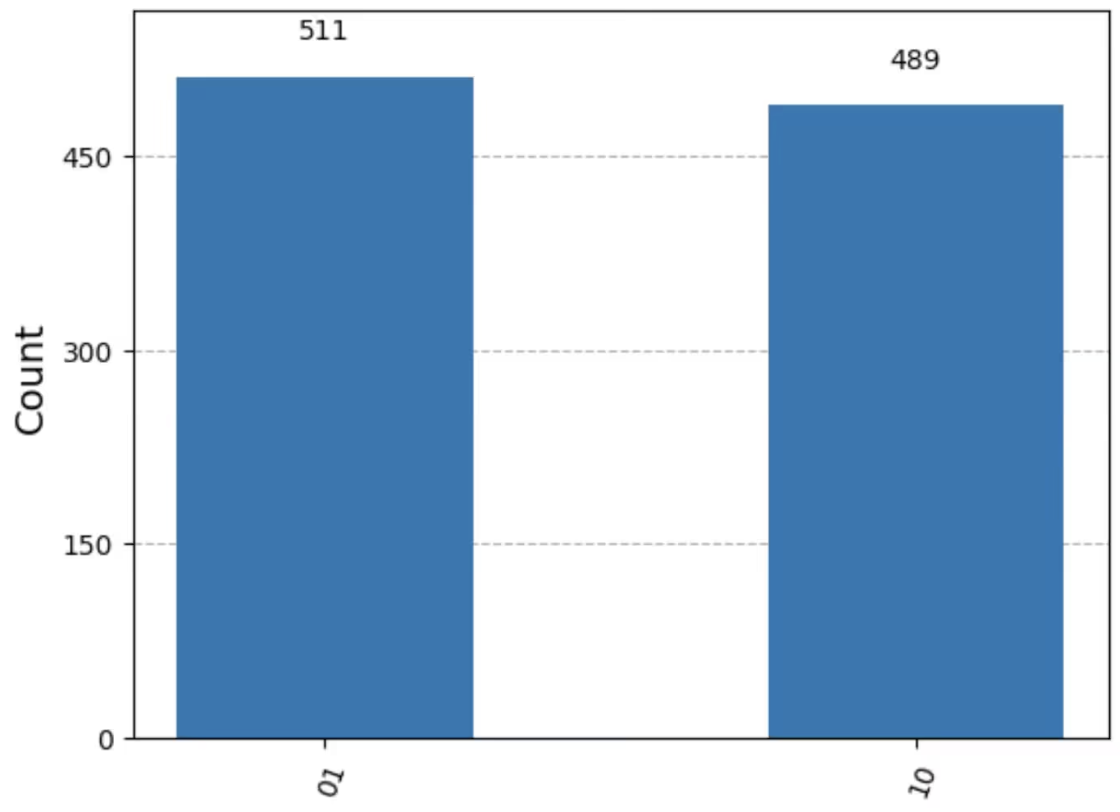

In [7]:
Image('teleportation4.png',width=600)

*a.* $\frac{1}{\sqrt{2}}\left(|0\rangle_B|0\rangle_A+|1\rangle_B|1\rangle_A\right)$

*b.* $\frac{4}{5}|0\rangle_B|0\rangle_A+\frac{3}{5}|1\rangle_B|1\rangle_A$

*c.* $\frac{1}{\sqrt{2}}\left(|0\rangle_B|1\rangle_A-|1\rangle_B|0\rangle_A\right)$

*d.* $\frac{4}{5}|0\rangle_B|1\rangle_A+\frac{3}{5}|1\rangle_B|0\rangle_A$

*e.* $|0\rangle_B|0\rangle_A$

**c**

**Discussion questions**

1. *Describe the quantum teleportation protocol, from start to finish, to your partner/group. See if they have anything to add, or if they have questions.*

Quantum teleportation allows an unknown qubit state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ to be transferred from Alice to Bob using two resources, a shared entangled pair between Alice and Bob and two classical bits sent from Alice to Bob.


The procedure follows as,
Preparation, Alice and Bob share an entangled Bell pair, for example  
   $|\Phi^+\rangle_{BA} = \frac{1}{\sqrt{2}}(|0\rangle_B|0\rangle_A + |1\rangle_B|1\rangle_A)$.

 
Alice possesses a third qubit $Q$ in the unknown state $|\psi\rangle_Q = \alpha|0\rangle + \beta|1\rangle$. Alice applies a CNOT gate between $Q$ (control) and her entangled qubit $A$ (target), followed by a Hadamard gate on $Q$.

Measurement, Alice measures both $Q$ and $A$ in the computational basis, obtaining two classical bits. Alice sends her two measurement results to Bob through a classical channel.


Correction, depending on the received bits, Bob applies one of four corrections to his qubit if Alice measures $|00\rangle_{AQ}$, Bob does nothing, if she measures $|01\rangle_{AQ}$ he applies $Z$, if she measures $|10\rangle_{AQ}$ he applies $X$, if she measures $|11\rangle_{AQ}$ he applies $X$ and then $Z$.

After these steps, Bob’s qubit is in the state $|\psi\rangle$.


2. *Is there anything unique about the initial entangled state between Alice and Bob: $|\Phi^+\rangle_{BA} = \frac{1}{\sqrt{2}}(|0\rangle_B|0\rangle_A + |1\rangle_B|1\rangle_A)$? If so, what is unique about it? If not, what other entangled states could we have used?*

The shared state $|\Phi^+\rangle_{BA} = \frac{1}{\sqrt{2}}(|0\rangle_B|0\rangle_A + |1\rangle_B|1\rangle_A)$
is one of the four Bell states, all of which are maximally entangled. There is nothing uniquely essential about $|\Phi^+\rangle$, any Bell state can be used for teleportation.  
The other three are,
$|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|0\rangle_B|0\rangle_A - |1\rangle_B|1\rangle_A),$
$|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|0\rangle_B|1\rangle_A + |1\rangle_B|0\rangle_A),$ and
$|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|0\rangle_B|1\rangle_A - |1\rangle_B|0\rangle_A).$

The only difference is which correction gates Bob must apply at the end.